# ESP memory system under DMA load: the 4x4 campaign

**13 accelerators, one memory tile, Xilinx VCU118 (xcvu9p).**

Three bitstreams differing only in how many AXI reads the memory-tile DMA proxy may keep in
flight -- 1 (stock ESP), 2, and 4. 504 measured runs per arm plus one idle calibration run,
3168 accelerator rows, zero errors, zero timeouts, zero malformed rows in all three captures.

## What this campaign found

**Nothing in the memory system is the bottleneck.** At the longest descriptors the DRAM runs
at **5.9%** of its bandwidth and the port into it at **50%**. The limit is upstream of both.

**The limit at long descriptors is that one accelerator is served at a time.** Aggregate
throughput settles at exactly one accelerator's absorption rate -- 625 MB/s -- whether 1 or 13
accelerators are running.

**It is not a ceiling.** The same path reaches **1102 MB/s** (88% of the port) at 32-beat
descriptors, where the proxy switches destination often enough to feed more than one
accelerator at once.

**Longest is not fastest.** Moving identical data, the baseline finishes quickest with
**64-beat** descriptors; 16384-beat descriptors are 15% slower and 8-beat are 3.5x slower.

**multiOT shortens service time, which is why it helps where it does.** It gives up to
**3.10x** at short descriptors and high fan-in, exactly nothing at 4096 beats and above, and
exactly nothing with one accelerator. It also costs up to 6.6% in one narrow band.

Sections 6-8 separate what this establishes from what it does not from what stays open.
Every number is computed from the raw CSVs by `charlib.py`.


In [1]:
# Colab bootstrap. A no-op anywhere else.
import os, sys, subprocess
REPO = "https://github.com/eugeniomuscinelli/esp-mem-characterization.git"
if "google.colab" in sys.modules and not os.path.isfile("charlib.py"):
    name = REPO.rsplit("/", 1)[-1].removesuffix(".git")
    if not os.path.isdir(name):
        subprocess.run(["git", "clone", "--depth", "1", "-q", REPO], check=True)
    os.chdir(name)
print("working directory:", os.getcwd())


working directory: /home/eugenio/char_results


In [2]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
import charlib as cl

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120,
                     "font.size": 10, "figure.facecolor": "white"})

arms = cl.load_all("4x4")
g = cl.occupancy_all(arms)
for k, a in arms.items():
    print(f"{a.label:<30s} {len(a.runs):>5d} accelerator rows, "
          f"{a.runs.run_id.nunique():>3d} measured runs + 1 idle, {len(a.tile):>5d} tile rows")


baseline (no multiOT)           3168 accelerator rows, 504 measured runs + 1 idle,  8080 tile rows
multiOT depth 4, barrier on     3168 accelerator rows, 504 measured runs + 1 idle,  8080 tile rows
multiOT depth 2, barrier on     3168 accelerator rows, 504 measured runs + 1 idle,  8080 tile rows


---
# 1. The SoC

A 4x4 ESP mesh, 16 tiles:

```
        col 0        col 1        col 2        col 3
      +------------+------------+------------+------------+
row 0 | MEM        | CPU        | acc 0      | acc 1      |
      +------------+------------+------------+------------+
row 1 | acc 2      | acc 3      | acc 4      | acc 5      |
      +------------+------------+------------+------------+
row 2 | acc 6      | acc 7      | acc 8      | acc 9      |
      +------------+------------+------------+------------+
row 3 | acc 10     | acc 11     | acc 12     | IO         |
      +------------+------------+------------+------------+
```

One memory tile at (0,0), one Ariane RV64 CPU, **13 accelerators**, one IO tile. Hop distance
from the memory tile ranges from **1 to 5**.

**ESP caches are disabled** -- `CFG_L2_ENABLE = 0`, `CFG_LLC_ENABLE = 0`. Every DMA beat is
real DRAM traffic. This also means several stock ESP counters measure nothing (section 3).

**Two clock domains, ratio exactly 2:**

| domain | frequency | what runs there |
|---|---|---|
| memory tile + NoC | **156.25 MHz** (the MIG `ui_clk`) | the DMA proxy, every counter in `mem.csv` |
| accelerator, CPU, IO tiles | **78.125 MHz** | the accelerators, the CPU's `mcycle` |

Confirmed empirically: the memory tile's free-running counter advances at exactly twice the
CPU tile's in the same run.

## 1.1 The bandwidth ladder

Every percentage in this report is a fraction of one of these three numbers, so they are
worth fixing first.

| | width x rate | bandwidth | in beats per memory-tile cycle |
|---|---|---|---|
| **DDR4 chip** | 64 bit x 1250 MT/s | 10 GB/s | 8.0 |
| **MIG AXI port** -- what the SoC actually touches | 64 bit x 156.25 MHz | **1.25 GB/s** | **1.000** |
| **one accelerator's DMA port** | 64 bit x 78.125 MHz | 625 MB/s | 0.500 |

From `constraints/xilinx-vcu118-xcvu9p/ariane/mig.tcl`: `DDR4_AxiDataWidth {64}`,
`DDR4_TimePeriod {1600}`.

The second row is the real ceiling: **one 64-bit beat every memory-tile cycle**. The DDR4
behind it is **eight times wider**, so the SoC talks to a 10 GB/s memory through a 1.25 GB/s
window. DRAM saturation is not observable on this platform; you would need roughly 8x the
traffic this SoC can generate before the DRAM noticed.

The third row matters because it turns out to be where the long-descriptor limit sits.

## 1.2 The accelerator

`dma_proxy_16k_sysc_catapult`, a SystemC traffic generator compiled with Catapult HLS. It
performs no computation. Four registers configure it:

| register | APB offset | meaning |
|---|---|---|
| `wr_per_group` | 0x40 | write bursts per interleave group |
| `rd_per_group` | 0x44 | read bursts per interleave group |
| `burst` | 0x48 | beats per descriptor |
| `size` | 0x4c | total 64-bit words to read |

It holds **one PLM buffer of 16384 64-bit words (128 KiB)**, shared by reads and writes, so a
read burst and a write burst never overlap within one accelerator.

The XML `<param>` order is the exact reverse of the `conf_info_t` declaration order and must
stay that way: socketgen maps XML `param[0]` to the most significant bits of `conf_info`
while the Catapult Marshaller maps the first-declared field to the least significant bits.
Matching the orders silently crosses all four registers. Section 4 gives the hardware check.


---
# 2. What one run is, exactly

## 2.1 The data each accelerator moves

**Every run reads 65,536 beats = 512 KiB per accelerator.** That is `SIZE_BEATS`, and it never
changes across the sweep. What changes is how that fixed volume is chopped into requests.

A **descriptor** is one DMA request: *give me N 64-bit words starting at address X*. The
`burst` register sets N. So:

```
descriptors per accelerator = 65,536 / burst
```

8192 of them at burst 8; **four** at burst 16384.

A descriptor costs **3 NoC flits to send regardless of how much data it asks for** -- header,
address, length. That is measured, not assumed:


In [3]:
cl.run_anatomy(arms["baseline_ot1_gate0"])


,descriptors per accelerator,PLM words used,PLM fraction used,request flits measured,flits per descriptor
descriptor length (beats),,,,,
8,8192,8,0.0005,319488,3.0
16,4096,16,0.0010,159744,3.0
32,2048,32,0.0020,79872,3.0
64,1024,64,0.0039,39936,3.0
128,512,128,0.0078,19968,3.0
256,256,256,0.0156,9984,3.0
512,128,512,0.0312,4992,3.0
1024,64,1024,0.0625,2496,3.0
4096,16,4096,0.2500,624,3.0


Two things to read off this table.

**The flits-per-descriptor column is 3.00 at every descriptor length.** A request for 16384
beats costs exactly the same to send as a request for 8.

**The PLM is a landing window, not an accumulator.** The accelerator always writes into
`plm[0][0 .. burst-1]` and overwrites it on the next iteration, while the *memory* cursor
advances (`rd_idx += beats`). So at burst 8 it uses 8 of 16,384 words -- 0.05% of the buffer
-- and recycles them 8,192 times; only at burst 16384 is the PLM genuinely filled.

## 2.2 Why 65,536

`SIZE_BEATS` must be a whole multiple of the longest descriptor, because the TLB maps 1 MiB
chunks and a descriptor straddling a chunk boundary would be split into two transactions of
different lengths -- silently falsifying the burst axis. The longest descriptor is 16,384,
fixed by the PLM (`if (burst > PLM_WORD) burst = PLM_WORD`).

65,536 = **4 x 16,384**, so each accelerator issues four descriptors at the longest setting.
The factor of four is a judgement call, and it is the weakest number in the setup: see 4.3.

## 2.3 Traffic by read:write ratio

The read volume is fixed; writes are a multiple of it set by the ratio. **The mixes therefore
do not move equal bytes**, which matters whenever they are compared by throughput.


In [4]:
cl.traffic_by_mix(arms["baseline_ot1_gate0"])


,read beats,write beats,total beats,KiB per accelerator,PLM capacities
mix,,,,,
1:0,65792,39,65831,514,4.02
1:1,66048,65575,131623,1028,8.03
1:4,66816,262183,328999,2570,20.08
4:1,65856,16423,82279,643,5.02


A 1:4 run moves five times the total traffic of a read-only run. When section 5 reports that
balanced traffic reaches a higher fraction of the port than read-only, that is a statement
about bytes delivered per unit time, **not** about the same work finishing sooner.

## 2.4 The sweep

| axis | values | note |
|---|---|---|
| descriptor length | 8, 16, 32, 64, 128, 256, 512, 1024, 4096, 16384 | |
| concurrent accelerators | 1, 2, 4, 6, 8, 10, 13 | |
| read:write ratio | 1:0 and 1:1 at **all ten** descriptor lengths | 70 points each |
| | 4:1 and 1:4 at **burst 32 and 256 only** | 14 points each |

**168 operating points per arm**, 3 repetitions each = 504 measured runs, plus one idle
calibration run. Any statement below of the form "in any mix" is restricted to bursts 32 and
256 unless it concerns only 1:0 and 1:1.

## 2.5 What the harness does per run

1. Snapshot every monitor counter in every tile.
2. Re-latch and re-read the memory tile alone, immediately before starting (see 3.3).
3. Program the four registers on each active accelerator and start them, recording the
   dispersion of the start writes.
4. Poll to completion against a cycle budget.
5. Snapshot the counters again; store the difference.


---
# 3. What every monitor measures

Counters live in `esp_tile_csr.vhd`, one instance per tile, 32-bit, free-running, never
cleared; every CSV number is a software difference of two latched reads. Index *i* is read at
APB word *i*+1, word 0 being the burst register.

This section is long because several counters measure something other than what their names
say, and two measure nothing at all. Reading the CSVs without it will mislead.

## 3.1 Stock ESP counters

| column | one increment means | what it does **not** mean |
|---|---|---|
| `ddr_write_beats` (ESP: `ddr_accesses`) | one accepted AXI **W** beat at the DRAM port (`tile_mem.vhd:736-738`) | **Writes only.** ESP prints it as "Off-chip memory accesses". A read-only run moves 512 KiB per accelerator while this barely moves. Beats, not transactions. |
| `coh_reqs` | one flit popped from the plane-1 inbound queue | **Not coherence.** There is no L2 or LLC in this SoC; plane 1 is Ariane's uncached request path. Flits, not transactions. |
| `coh_fwds`, `coh_rsps_rcv` | nothing | **Structurally inert** -- their drivers live in the `with_cache_coherence` branch, which is not elaborated. Zero here is not an observation. |
| `coh_rsps_snd` | one flit pushed to plane 3 outbound | CPU read-data replies, not LLC responses. Accelerator DMA data is **not** here. |
| `dma_req_flits` | one flit popped from the DMA request queue (plane 6 in) | Not descriptors. `/3` gives a descriptor count only for read-only runs. |
| `dma_rsp_flits` | one flit pushed to the DMA response queue (plane 4 out) | Not equal to `ddr_read_beats`: it adds one header per descriptor and excludes CPU reads. |
| `coh_dma_reqs`, `coh_dma_rsps` | flits on the coherent-DMA queues | **These belong to the JTAG/EDCL/Ethernet bridge**, not to accelerator DMA. Zero says nothing about accelerator coherence. |
| `l2_hits/misses`, `llc_hits/misses` | nothing | Caches are disabled, *and* `libmonitors.c` writes the LLC reads into the L2 struct field, so `llc_stats[]` is never written at all. |
| `dvfs3` | one tile-clock cycle | A free-running clock reference, not a DVFS statistic. **Wide window** -- not comparable with `mem_cycles`. |
| `inject_p0..p5` | one flit injected by that tile on CSV plane *N* (= RTL plane *N*+1) | Flits, not packets. The same column means different traffic at different tiles. |
| `router_p*_d*` (ESP: `queue_full`) | one cycle a valid flit was present on that output port | **Not fullness and not backpressure**, despite ESP printing it as "NoC backpressure cycles". It is link utilization. |

## 3.2 The plane map

The two directions of one plane number carry unrelated traffic, and the `in`/`out` suffixes
are written from the **network's** point of view, not the tile's.

| RTL signal | CSV plane | direction | carries | used here |
|---|---|---|---|---|
| `noc4_in` | 3 | **memory tile -> accelerator** | DMA responses: read data | yes |
| `noc6_out` | 5 | **accelerator -> memory tile** | DMA requests: descriptors + write data | yes |
| `noc6_in` | 5 | memory tile -> accelerator | coherent DMA responses | no |
| `noc4_out` | 3 | accelerator -> memory tile | coherent DMA requests | no |

Verified against hardware counts rather than asserted:


In [5]:
t = arms["baseline_ot1_gate0"].tile; r = arms["baseline_ot1_gate0"].runs
run = r[(r.n_active == 13) & (r.burst == 16384) & (r.rd_per_group == 1)
        & (r.wr_per_group == 0) & (r.rep == 1)].run_id.iloc[0]
s = t[t.run_id == run]
inj = [c for c in t.columns if c.startswith("inject_p")]
display(s[["tile"] + inj].head(5))
print(f"memory tile injects {int(s[s.tile==0].inject_p3.iloc[0]):,} flits on CSV plane 3")
print(f"  = 13 x 65,536 read beats + {int(s[s.tile==0].inject_p3.iloc[0]) - 13*65536} "
      f"response headers (one per descriptor; 13 x 4 = 52 descriptors)")
print(f"each accelerator injects {int(s[s.tile==2].inject_p5.iloc[0])} flits on CSV plane 5")
print(f"  = 3 flits x 4 descriptors")


,tile,inject_p0,inject_p1,inject_p2,inject_p3,inject_p4,inject_p5
6688,0,0,0,114,852020,136,0
6689,1,3918,0,0,0,1182,0
6690,2,0,0,0,0,48,12
6691,3,0,0,0,0,49,12
6692,4,0,0,0,0,51,12


memory tile injects 852,020 flits on CSV plane 3
  = 13 x 65,536 read beats + 52 response headers (one per descriptor; 13 x 4 = 52 descriptors)
each accelerator injects 12 flits on CSV plane 5
  = 3 flits x 4 descriptors


## 3.3 Counters added for this campaign

| column | one increment means | what it does **not** mean |
|---|---|---|
| `ddr_read_beats` | one accepted AXI **R** beat at the DRAM port | Beats, not requests. Includes the CPU's and the Ethernet bridge's reads, not only DMA. |
| `ddr_read_busy` | one cycle with **>=1** AXI read outstanding | Not DRAM utilization. A port busy by this measure can deliver almost no bandwidth. |
| `ddr_read_multi` | one cycle with **>=2** outstanding | Zero by construction in the baseline proxy. Non-zero values aggregate every master on the port, not only the DMA proxy. |
| `dma_snd_blocked` | one cycle the outbound response FIFO was **full** (18 flits) | Real backpressure -- the proxy's `R_READY` is gated on `!dma_snd_full` (`noc2aximst.sv:787`). But it is an occupancy at the ceiling, not a count of blocked pushes; shallower congestion is invisible. |
| `dma_rcv_starved` | one cycle the inbound request FIFO was **empty** | **Not "the tile had no work".** While streaming a long read the proxy consumes no requests, so an empty queue is the normal state at peak throughput. Read it as request-queue headroom. |
| `noc_stop_rsp` | one cycle the tile's plane-4 injection CDC FIFO (8 entries) reported **full** | **Raw, not qualified by a flit being offered** -- the qualification is commented out in `sync_noc_xy.vhd:177`. |
| `noc_stop_req` | one cycle the network **was offering** a plane-6 request flit and the 18-flit inbound FIFO was full | Not network congestion -- this tile refusing. |
| `mem_cycles` | one memory-tile clock cycle, unconditionally | Not CPU cycles. 32-bit, wraps every ~27.5 s. |

**`noc_stop_rsp` and `noc_stop_req` are not directly comparable as occupancies.** One is raw
and watches an 8-entry CDC FIFO; the other is qualified and watches an 18-flit socket queue.
Comparisons between them in section 5 are about *trend*, not about relative magnitude.

## 3.4 Two measurement windows in one CSV row

The burst register latches `count` into `count_value` on a rising edge, so a snapshot is
consistent across every counter in a tile. The harness takes a full snapshot, then re-latches
and re-reads **the memory tile alone** immediately before starting the accelerators, which
shrinks the dead time from roughly 700 MMIO reads to about 17.

That re-latch covers **nine fields only** -- `ddr_write_beats`, `ddr_read_beats`,
`ddr_read_busy`, `ddr_read_multi`, `dma_snd_blocked`, `dma_rcv_starved`, `noc_stop_rsp`,
`noc_stop_req`, `mem_cycles`. Every other `mem.csv` column and all of `tile.csv` keeps the
wider snapshot, which also contains the pre-run monitor reads.

Consequences: `mem_cycles` is an exact denominator for the nine, and **only** for the nine.
`coh_reqs` carries a floor of a few thousand flits in every run regardless of length, because
the monitor reads themselves are CPU traffic. `dvfs3` and `mem_cycles` are not the same
window. Counts of events that only occur during the run (`dma_req_flits`, `inject_p*`) are
unaffected by the wider window, since no such events happen while the CPU is reading monitors.


---
# 4. Validation


In [6]:
for k, a in arms.items():
    it = cl.integrity(a); bad = sum(a.dropped.values())
    ok = it["data_errors"] == 0 and it["timeouts"] == 0 and bad == 0
    print(f"{a.label:<30s} rows {it['acc_rows']:>5d}  configs {it['configs']:>3d}  "
          f"errors {it['data_errors']}  timeouts {it['timeouts']}  "
          f"malformed {bad}   {'PASS' if ok else 'CHECK'}")


baseline (no multiOT)          rows  3168  configs  24  errors 0  timeouts 0  malformed 0   PASS
multiOT depth 4, barrier on    rows  3168  configs  24  errors 0  timeouts 0  malformed 0   PASS
multiOT depth 2, barrier on    rows  3168  configs  24  errors 0  timeouts 0  malformed 0   PASS


**4.1 Correctness.** Zero data errors, zero timeouts, zero malformed rows. The register
cross-check verifies the programmed ratio against the memory tile's own write counter rather
than against software:


In [7]:
w = cl.write_ratio_check(arms["baseline_ot1_gate0"])
w["ratio"] = w["rd_per_group"].astype(str) + ":" + w["wr_per_group"].astype(str)
display(w[["ratio", "runs", "write_beats/expected", "read_beats/expected"]])

rows = []
for k, a in arms.items():
    o = cl.occupancy(a); r = {"arm": a.label}
    for c in ("dma_rcv_starved", "dma_snd_blocked", "noc_stop_rsp", "noc_stop_req"):
        r[c] = f"max {100*(o[c]/o.mem_cyc).max():.1f}%, over 100%: {int((100*o[c]/o.mem_cyc > 100.0001).sum())}"
    rows.append(r)
display(pd.DataFrame(rows).set_index("arm"))


,ratio,runs,write_beats/expected,read_beats/expected
0,1:0,210.0,NaN,1.007061
1,1:1,210.0,1.002355,1.011140
2,1:4,42.0,1.000589,1.026774
3,4:1,42.0,1.009418,1.007927


,dma_rcv_starved,dma_snd_blocked,noc_stop_rsp,noc_stop_req
arm,,,,
baseline (no multiOT),"max 100.0%, over 100%: 0","max 44.7%, over 100%: 0","max 49.4%, over 100%: 0","max 98.3%, over 100%: 0"
"multiOT depth 4, barrier on","max 100.0%, over 100%: 0","max 49.5%, over 100%: 0","max 49.6%, over 100%: 0","max 97.0%, over 100%: 0"
"multiOT depth 2, barrier on","max 100.0%, over 100%: 0","max 49.5%, over 100%: 0","max 49.6%, over 100%: 0","max 97.9%, over 100%: 0"


**4.2 Occupancies are bounded by their own denominator.** No counter exceeds `mem_cycles` in
any of the 1515 memory-tile rows. (`dma_rcv_starved` reaches exactly 100.0% in three rows --
the idle calibration run of each arm, where the tile genuinely has nothing queued for the
whole window. Over the 1512 real runs the maximum is 99.99%.)

**4.3 Launch stagger -- a real limitation at long descriptors.** The CPU programs
accelerators one at a time, which costs a fixed ~180,500 cycles at 13 accelerators.


In [8]:
r = arms["baseline_ot1_gate0"].runs
per = r.groupby("run_id").agg(n=("n_active", "first"), b=("burst", "first"),
                              last_start=("start_off", "max"), run=("cyc_all_done", "max"))
per["stagger %"] = 100 * per.last_start / per.run
display(per.groupby("n")["stagger %"].agg(["median", "max"]).round(2))
worst = per.loc[per["stagger %"].idxmax()]
print(f"worst: {worst['stagger %']:.1f}% at {int(worst.n)} accelerators, "
      f"burst {int(worst.b)}")
print(f"points over 10%: {(per['stagger %'] > 10).sum()} of {len(per)}")


,median,max
n,,
1,0.00,0.01
2,0.05,0.11
4,0.15,12.58
6,0.17,16.70
8,0.18,18.78
10,0.19,20.03
13,0.19,21.17


worst: 21.2% at 13 accelerators, burst 16384
points over 10%: 21 of 504


The median is negligible (0.19% at 13 accelerators) but the **maximum is 21.2%**, and it
falls on the long-descriptor points -- which finish quickest in wall-clock terms and so pay
the fixed launch cost hardest. Those are exactly the points section 5.2 rests on.

This traces directly to `SIZE_BEATS = 4 x PLM` (section 2.2). Raising it to 278,528 beats
would put the stagger under 5% at a cost of 4x longer runs -- about 22 seconds of DMA time
per arm instead of 5.2. Any re-run should do that.

**4.4 Repeatability.** Median repeat spread is ~0.03%, but it is not uniform: the noisiest
single point in the campaign is baseline / balanced / 2 accelerators / burst 64, at a 6.05%
range across its three repetitions -- roughly 200x the median. Section 5.5 depends on that
point and says so.


In [9]:
rows = []
for k, a in arms.items():
    c = pd.concat([cl.completion(a, r_, w_).assign(ratio=f"{r_}:{w_}")
                   for r_, w_ in a.runs.groupby(["rd_per_group",
                                                 "wr_per_group"]).groups.keys()])
    rows.append(pd.Series({"arm": a.label, "median spread %": c["spread_pct"].median(),
                           "90th pct %": c["spread_pct"].quantile(0.9),
                           "worst %": c["spread_pct"].max()}))
pd.DataFrame(rows).round(3)


,arm,median spread %,90th pct %,worst %
0,baseline (no multiOT),0.019,0.104,6.188
1,"multiOT depth 4, barrier on",0.047,1.006,6.156
2,"multiOT depth 2, barrier on",0.035,0.516,5.215


---
# 5. Results

## 5.1 Where the bottleneck is not

Every candidate limit in the path, with the utilisation actually reached:


In [10]:
cl.bottleneck_ladder(arms)


,capacity,reached at long descriptors,best reached anywhere
resource,,,
DDR4 chip,10 GB/s,6.2%,11.0%
MIG AXI port,1.25 GB/s,49.8%,88.2%
outbound NoC path (read data),not independently known,49.8%,68.0% (read-only ceiling)


**The DDR4 runs at 6.2% at long descriptors and never exceeds 11% anywhere.** It is not in
play, and cannot be on this platform: the MIG AXI port is configured 64 bits wide, so the SoC
reaches a 10 GB/s memory through a 1.25 GB/s window.

**The MIG AXI port is idle half the time at long descriptors.** 49.8% utilisation means
50.2% of port cycles carry no beat. A resource idle on half its cycles is not the constraint.
The same port demonstrably carries 88.2% elsewhere.

**The port cannot explain the mix dependence either**, which is the decisive argument against
it. An AXI port is direction-agnostic -- a beat is a beat. If the port were the limit, every
read:write mix would top out at the same number:


In [11]:
rows = []
for (rd, wr), s in g.groupby(["rd", "wr"]):
    b = s.loc[s.tot_beats_per_cyc.idxmax()]
    rows.append({"mix": f"{int(rd)}:{int(wr)}",
                 "best % of port": round(100 * b.tot_beats_per_cyc, 1),
                 "at descriptor": int(b.burst), "at n_active": int(b.n_active)})
pd.DataFrame(rows).set_index("mix")


,best % of port,at descriptor,at n_active
mix,,,
1:0,68.0,32,13
1:1,88.2,32,13
1:4,78.7,32,13
4:1,80.1,32,13


They do not: balanced beats read-only by **20 points**. Reads return outbound on plane 4,
writes arrive inbound on plane 6, so read-only forces every byte through one direction while
balanced traffic uses two independent paths. That is a per-direction path limit, and the port
cannot produce it.

**Read traffic alone never exceeds 68% of the port anywhere in the campaign.**

## 5.2 What the long-descriptor limit is

At the longest descriptors the aggregate settles on one accelerator's absorption rate,
independent of how many accelerators are running.


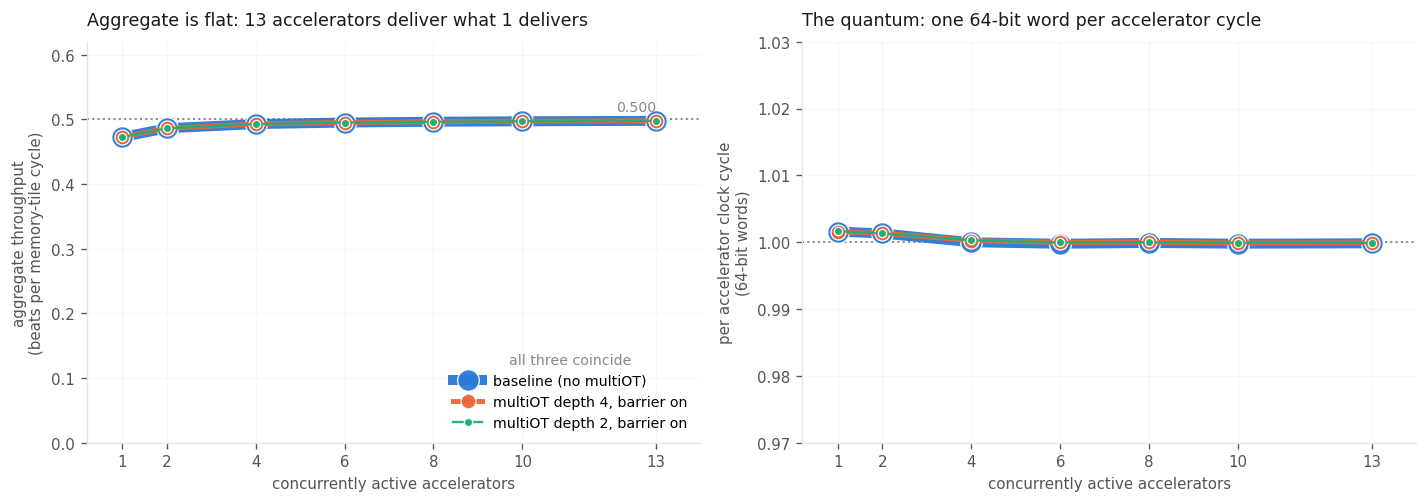

,label,n_active,tot_beats_per_cyc,per_acc,words_per_acc_cyc,noc_stop_rsp_pct
0,baseline (no multiOT),1,0.472515,0.472515,1.001588,46.681293
1,baseline (no multiOT),2,0.486064,0.243032,1.001301,48.138483
2,baseline (no multiOT),4,0.492600,0.123150,0.999984,48.867294
3,baseline (no multiOT),6,0.494924,0.082487,0.999764,49.109440
4,baseline (no multiOT),8,0.496215,0.062027,0.999885,49.262387
5,baseline (no multiOT),10,0.496901,0.049690,0.999771,49.328316
6,baseline (no multiOT),13,0.497616,0.038278,0.999832,49.402834
7,"multiOT depth 2, barrier on",1,0.472536,0.472536,1.001649,46.798421
8,"multiOT depth 2, barrier on",2,0.486068,0.243034,1.001312,48.300535
9,"multiOT depth 2, barrier on",4,0.492746,0.123186,1.000291,49.065634


In [12]:
fig = cl.plot_quantum(arms); plt.show()
cl.per_accelerator_share(arms, burst=16384, rdg=1, wrg=0)


`words_per_acc_cyc` is the aggregate expressed in the accelerator clock. **It is not a
per-accelerator figure** -- the numerator is the total across all active accelerators. At 13
accelerators each one individually is running at about 7.7% of its own port.

Because one accelerator absorbs at most one 64-bit word per its own 78.125 MHz cycle, this
ratio reads as **how many accelerators were effectively being served at once**. The reading is
safe rather than assumed because it never exceeds the number present anywhere in the campaign
(maximum ratio to `n_active`: 1.002).


In [13]:
cl.effective_concurrency(arms)


,baseline (no multiOT),"multiOT depth 4, barrier on","multiOT depth 2, barrier on"
descriptor length (beats),,,
8,0.339,1.054,0.616
16,0.558,1.364,1.007
32,0.847,1.368,1.334
64,1.160,1.199,1.172
128,1.065,1.090,1.074
256,1.027,1.040,1.033
512,1.011,1.020,1.015
1024,1.006,1.009,1.008
4096,1.002,1.002,1.002


Three regimes, visible in one column:

- **below 1.0** -- not even one accelerator kept fed. Latency-bound.
- **around 1.0** -- exactly one served at a time. This is the long-descriptor plateau.
- **above 1.0** -- several served concurrently. This is where the peak is, reaching **1.77**
  in balanced traffic at 32-beat descriptors.

So the plateau is not a ceiling of anything: it is the value the aggregate takes when the
proxy is locked onto a single destination for the duration of a descriptor. At 16384 beats
that is about 32,945 cycles per descriptor, during which the other twelve accelerators wait.

The counters show the same thing from the memory side: at the plateau the AXI read channel is
occupied 97.65% of cycles but delivers only **0.51 beats per occupied cycle**, while the
response path refuses the tile 49.4% of the time. The proxy's `R_READY` is gated on the
response FIFO not being full (`noc2aximst.sv:787`), so when the drain backs up the AXI read
stays outstanding and the channel looks busy while the DRAM idles.

**What is measured and what is inferred.** The rates, the occupancies and the bound at
`n_active` are measured. "The proxy serves one descriptor at a time" is inferred -- no counter
observes destination concurrency directly.

## 5.3 Total running time: who finishes first

Same data moved in every row.


In [14]:
display(cl.elapsed_comparison(arms, rdg=1, wrg=0))
b = cl.elapsed_comparison(arms, rdg=1, wrg=0)[cl.LABEL["baseline_ot1_gate0"]]
print(f"baseline optimum: burst {b.idxmin()} at {b.min():,.0f} cycles "
      f"({b.min()/cl.ACC_CLK_HZ*1e3:.2f} ms)")
print(f"longest descriptor: {b.loc[16384]:,.0f} cycles -> "
      f"{b.loc[16384]/b.min():.2f}x the optimum")
print(f"shortest descriptor: {b.loc[8]:,.0f} cycles -> {b.loc[8]/b.min():.2f}x the optimum")


,"baseline, ms",baseline (no multiOT),"multiOT depth 4, barrier on","multiOT depth 2, barrier on",vs baseline optimum
descriptor length (beats),,,,,
8,33.0,2568123.0,813864.0,1400155.0,3.0
16,20.0,1546216.0,628099.0,852249.0,2.0
32,13.0,1014429.0,625483.0,642418.0,1.0
64,9.0,738610.0,712675.0,730187.0,1.0
128,10.0,804671.0,783858.0,796377.0,1.0
256,11.0,833238.0,820204.0,826657.0,1.0
512,11.0,844855.0,836554.0,840730.0,1.0
1024,11.0,847906.0,844793.0,845738.0,1.0
4096,11.0,851358.0,851318.0,851300.0,1.0


baseline optimum: burst 64 at 738,610 cycles (9.45 ms)
longest descriptor: 852,675 cycles -> 1.15x the optimum
shortest descriptor: 2,568,123 cycles -> 3.48x the optimum


**The baseline's optimum is 64-beat descriptors, not the longest.** 16384-beat descriptors
take 15% longer; 8-beat take 3.5x longer.

Everything upstream of the memory tile prefers long descriptors -- fewer requests, fewer
flits, less NoC traffic. The 15% penalty is the serialization cost of holding the server on
one destination for 32,945 cycles at a time.

multiOT depth 4 finishes fastest at **32-beat** descriptors: the feature does not merely
raise the peak, it moves it toward shorter descriptors, because it makes them cheap enough
that their better destination-switching wins.

## 5.4 What multiOT changes: service time

The mechanism is visible directly. Service time is the cycles the tile spends on one
descriptor, during which it refuses everything else offered.


In [15]:
cl.service_time(arms)


baseline (no multiOT)                 multiOT depth 4, barrier on                 multiOT depth 2, barrier on                
                                 service cycles inbound stall %              service cycles inbound stall %              service cycles inbound stall %
descriptor length (beats)                                                                                                                              
8                                          47.0            93.5                        15.0            31.0                        26.0            86.0
16                                         57.0            94.4                        24.0            44.0                        32.0            89.0
32                                         76.0            95.4                        47.0            76.5                        48.0            92.6
64                                        111.0            96.4                       107.0            91.8                       110.0            96.2
128                                       242.0            97.9                       236.0            96.9                       240.0            97.6
256                                       501.0            98.3                       495.0            96.5                       498.0            97.9
512                                      1018.0            98.2                      1010.0            95.2                      1014.0            97.3
1024                                     2046.0            97.3                      2040.0            94.0                      2041.0            95.8
4096                                     8222.0            91.8                      8222.0            91.8                      8221.0            91.8
16384                                   32945.0            68.8                     32942.0            68.8                     32943.0            68.8

**Short descriptors:** depth 4 cuts service time to a third (47 -> 15 cycles at burst 8), and
inbound refusal collapses with it (93.5% -> 31.0%).

**Long descriptors:** service time is identical to the cycle across all three arms (32,945 /
32,942 / 32,943), and inbound refusal is identical to the decimal (68.8% in all three).

`ddr_read_multi` is high at 16384 beats -- the proxy **is** pipelining its 256-beat AXI
segments as designed. It buys nothing, because the constraint is downstream of the DRAM
fetch. Eager issue fills the pipe faster; the pipe still empties into a destination that takes
one beat every two cycles.

The crossover is at 64 beats, where the three arms' service times converge within 4 cycles.

## 5.5 Speedup, and where multiOT costs


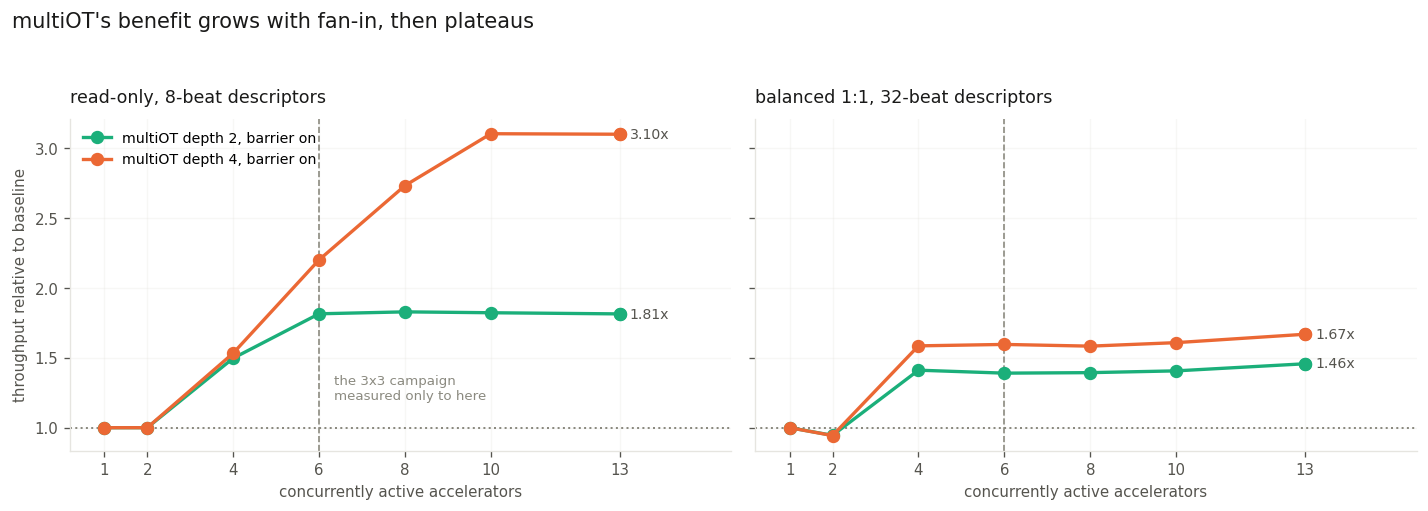

depth 4 over baseline -- read-only


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,1.0,1.000,1.533,2.201,2.732,3.103,3.099
16,1.0,1.022,1.667,2.111,2.423,2.428,2.433
32,1.0,1.039,1.405,1.486,1.533,1.550,1.611
64,1.0,1.000,1.015,1.019,1.017,1.015,1.034
128,1.0,1.001,1.017,1.017,1.019,0.997,1.023
256,1.0,1.000,1.014,1.016,1.017,1.014,1.013
512,1.0,0.999,1.007,1.005,1.005,1.005,1.008
1024,1.0,1.000,1.004,1.002,1.003,1.002,1.003
4096,1.0,1.000,1.000,1.000,1.000,1.000,1.000


depth 4 over baseline -- balanced 1:1


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,1.0,1.034,1.574,1.951,2.025,2.024,2.034
16,1.0,0.967,1.260,1.892,1.819,1.852,1.891
32,1.0,0.944,1.585,1.596,1.583,1.609,1.669
64,1.0,0.940,1.000,1.088,1.260,1.266,1.277
128,1.0,1.000,0.985,1.351,1.201,1.217,1.220
256,1.0,1.000,1.003,1.325,1.224,1.225,1.235
512,1.0,1.000,1.004,1.228,1.219,1.220,1.218
1024,1.0,1.000,1.127,1.053,1.166,1.198,1.221
4096,1.0,1.000,1.000,1.000,1.000,1.000,1.000


In [16]:
fig = cl.plot_speedup_vs_fanin(arms); plt.show()
for rd, wr, nm in [(1, 0, "read-only"), (1, 1, "balanced 1:1")]:
    s = g[(g.rd == rd) & (g.wr == wr)].pivot_table(
        index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
    print(f"depth 4 over baseline -- {nm}")
    display((s["multiot_ot4_gate1"] / s["baseline_ot1_gate0"]).round(3))


**The benefit grows with fan-in and then plateaus.** Read-only at burst 8: 1.53x at 4
accelerators, 2.20x at 6, 2.73x at 8, **3.10x at 10**, 3.10x at 13.

**Nothing at one accelerator**, at any descriptor or depth. `esp_acc_dma` is untouched in
every arm and issues one transaction at a time, so a single accelerator presents the memory
tile with one outstanding request however deep the proxy is.

**Nothing at 4096 beats and above**, in every mix at every concurrency.

**And multiOT is slower in a narrow band:**


In [17]:
rows = []
for rd, wr, nm in [(1, 0, "1:0"), (1, 1, "1:1"), (4, 1, "4:1"), (1, 4, "1:4")]:
    s = g[(g.rd == rd) & (g.wr == wr)].pivot_table(
        index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
    for arm, nm2 in [("multiot_ot4_gate1", "depth 4"), ("multiot_ot2_gate1", "depth 2")]:
        r_ = (s[arm] / s["baseline_ot1_gate0"]).stack()
        for (burst, n), v in r_[r_ < 0.995].items():
            rows.append({"arm": nm2, "mix": nm, "burst": burst, "n_active": n,
                         "speedup": round(v, 3)})
pd.DataFrame(rows).sort_values("speedup")


,arm,mix,burst,n_active,speedup
9,depth 2,1:4,32,2,0.934
8,depth 4,1:4,32,2,0.934
2,depth 4,1:1,64,2,0.940
6,depth 2,1:1,64,2,0.940
1,depth 4,1:1,32,2,0.944
5,depth 2,1:1,32,2,0.945
4,depth 2,1:1,16,2,0.966
0,depth 4,1:1,16,2,0.967
7,depth 2,1:1,128,4,0.973
3,depth 4,1:1,128,4,0.985


The worst regression in the campaign is **write-heavy traffic, 2 accelerators, 32-beat
descriptors: -6.6%** in both multiOT arms. A balanced-traffic band at 2 accelerators (bursts
16-64) loses up to 6.0%.

Read-only shows no regression anywhere in the sweep, which points at an interaction with
writes. The posted-write barrier is the obvious suspect and is untested -- no barrier-off arm
was built.

One caveat on the balanced band: its worst point coincides with the noisiest point in the
campaign (6.05% repeat range, section 4.4). The write-heavy regression does not -- its repeat
spread is under 0.04% -- so it is the better-supported of the two.

## 5.6 Outstanding depth: 4 against 2


In [18]:
s = g[(g.rd == 1) & (g.wr == 0)].pivot_table(
    index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
display((s["multiot_ot4_gate1"] / s["multiot_ot2_gate1"]).round(3))
s2 = g[(g.rd == 1) & (g.wr == 1)].pivot_table(
    index="burst", columns=["arm", "n_active"], values="tot_beats_per_cyc")
r2 = (s2["multiot_ot4_gate1"] / s2["multiot_ot2_gate1"]).stack()
print("balanced points where depth 4 is WORSE than depth 2:")
display(r2[r2 < 0.98].round(3))


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,1.000,1.000,1.024,1.213,1.494,1.703,1.708
16,1.000,1.000,1.063,1.174,1.354,1.353,1.352
32,1.000,1.000,1.001,1.030,1.029,1.034,1.025
64,1.000,1.001,1.015,1.011,0.988,0.998,1.023
128,1.000,1.000,1.008,1.005,1.007,0.984,1.015
256,1.001,1.000,1.006,1.002,1.001,1.002,1.007
512,1.000,1.000,1.003,1.004,1.001,1.001,1.004
1024,1.000,1.000,1.001,1.000,1.000,1.000,1.001
4096,1.000,1.000,1.000,1.000,1.000,1.000,1.000


balanced points where depth 4 is WORSE than depth 2:


burst  n_active
16     4           0.907
64     4           0.729
dtype: float64

In read-only, depth 4's advantage **grows with fan-in**: 1.000 at 1-2 accelerators, 1.213 at
6, **1.708 at 10 and 13**. At 6 accelerators the two depths look nearly equivalent; they are
not.

**But depth is not monotone.** In balanced traffic at 4 accelerators and 64-beat descriptors,
depth 2 gains 1.371x over the baseline while depth 4 gains 1.0002x -- depth 4 loses an entire
37% gain that depth 2 captures at the identical operating point. Any claim of the form "deeper
is better" needs this exception.

## 5.7 Inbound backpressure

`noc_stop_req` was inert in the 3x3 campaign -- wired to a queue this workload never uses. It
is live here.


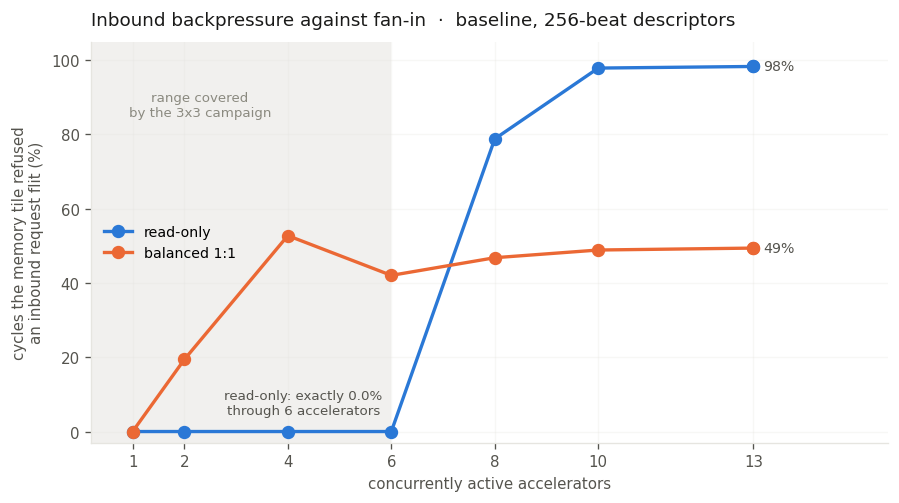

baseline, read-only, inbound refusal as % of memory-tile cycles


n_active,1,2,4,6,8,10,13
burst,,,,,,,
8,0.0,0.0,0.0,0.0,9.9,93.5,93.5
16,0.0,0.0,0.0,0.0,10.4,94.3,94.4
32,0.0,0.0,0.0,0.0,9.4,95.2,95.4
64,0.0,0.0,0.0,0.0,4.8,96.2,96.4
128,0.0,0.0,0.0,0.0,54.6,97.6,97.9
256,0.0,0.0,0.0,0.0,78.8,97.9,98.3
512,0.0,0.0,0.0,0.0,86.7,97.5,98.2
1024,0.0,0.0,0.0,0.0,88.6,96.1,97.3
4096,0.0,0.0,0.0,0.0,74.2,87.4,91.8


In [19]:
fig = cl.plot_inbound_onset(arms); plt.show()
b = g[(g.arm == "baseline_ot1_gate0") & (g.rd == 1) & (g.wr == 0)]
print("baseline, read-only, inbound refusal as % of memory-tile cycles")
display(b.pivot_table(index="burst", columns="n_active",
                      values="noc_stop_req_pct").round(1))


In read-only it is **exactly 0.0% at 1, 2, 4 and 6 accelerators** and reaches **93-98% at 10
and 13**. In balanced traffic the onset is earlier, around 4 accelerators -- the inbound path
then carries write data as well as descriptors, though this campaign does not separate those
two contributions.

**It is not what limits throughput**, and section 5.4 says why: it is service time seen from
the network side. The tile accepts a descriptor's 3 flits, then refuses everything offered for
however long that descriptor takes.


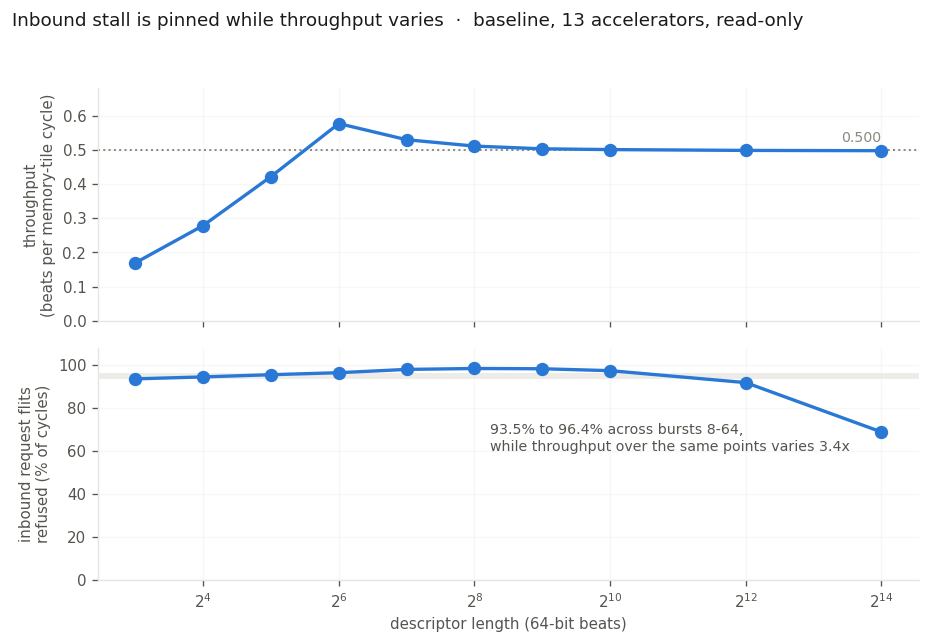

over all 168 baseline operating points:
  corr(throughput, inbound refusal)  = +0.161
  corr(throughput, outbound refusal) = +0.469


In [20]:
fig = cl.plot_inbound_not_the_limit(arms); plt.show()
bb = g[g.arm == "baseline_ot1_gate0"]
print(f"over all {len(bb)} baseline operating points:")
print(f"  corr(throughput, inbound refusal)  = {bb.tot_beats_per_cyc.corr(bb.noc_stop_req_pct):+.3f}")
print(f"  corr(throughput, outbound refusal) = {bb.tot_beats_per_cyc.corr(bb.noc_stop_rsp_pct):+.3f}")


At 13 accelerators, read-only, inbound refusal moves only from 93.5% to 96.4% across
descriptors 8 to 64 while throughput over the same points moves 3.4x. Both correlations with
throughput are positive.

## 5.8 Fairness

With 13 accelerators contending on one non-preemptive server, are they served equally?


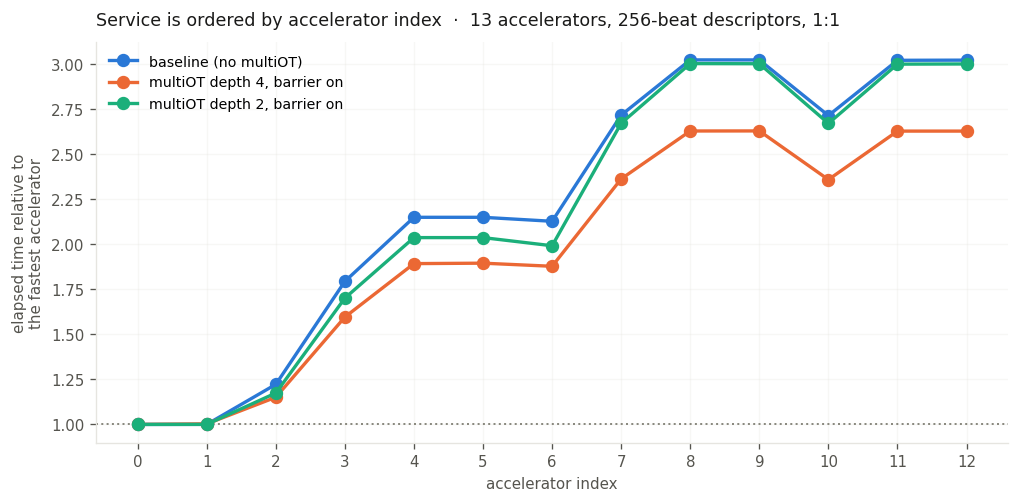

mix,balanced 1:1,read-only
arm,,
baseline (no multiOT),3.023,1.193
"multiOT depth 2, barrier on",3.003,1.101
"multiOT depth 4, barrier on",2.629,1.103


baseline, balanced, 256-beat descriptors -- fairness against fan-in


n_active,1,2,4,6,8,10,13
slowest/fastest,1.0,1.002,1.003,1.366,2.0,2.345,3.023


In [21]:
fig = cl.plot_fairness_by_index(arms); plt.show()
rows = []
for k in cl.ARM_ORDER:
    r = arms[k].runs
    for rd, wr, nm in [(1, 0, "read-only"), (1, 1, "balanced 1:1")]:
        s = r[(r.n_active == 13) & (r.burst == 256) & (r.rd_per_group == rd)
              & (r.wr_per_group == wr)]
        per = s.groupby("acc").cyc_active.mean()
        rows.append({"arm": cl.LABEL[k], "mix": nm,
                     "slowest/fastest": round(per.max() / per.min(), 3)})
display(pd.DataFrame(rows).pivot(index="arm", columns="mix", values="slowest/fastest"))

r = arms["baseline_ot1_gate0"].runs
rows = []
for n in sorted(r.n_active.unique()):
    s = r[(r.n_active == n) & (r.burst == 256) & (r.rd_per_group == 1)
          & (r.wr_per_group == 1)]
    per = s.groupby("acc").cyc_active.mean()
    rows.append({"n_active": n, "slowest/fastest": round(per.max() / per.min(), 3)})
print("baseline, balanced, 256-beat descriptors -- fairness against fan-in")
display(pd.DataFrame(rows).set_index("n_active").T)


**Unfairness is a write-traffic phenomenon.** In read-only at 13 accelerators the spread is
only about 1.1x; the 3.02x figure appears once writes are present.

**It degrades monotonically with fan-in** -- 1.000, 1.002, 1.003, 1.366, 2.000, 2.345, 3.023
at 1 through 13 accelerators -- on one bitstream at one operating point.

Depth 4 improves it to 2.63x; depth 2 does not (3.00x).

## 5.9 Placement: index or distance?


In [22]:
r = arms["baseline_ot1_gate0"].runs
s = r[(r.n_active == 13) & (r.burst == 256) & (r.rd_per_group == 1) & (r.wr_per_group == 1)]
t = s.groupby(["acc", "acc_y", "acc_x", "hops"]).cyc_active.mean().reset_index()
t["relative to fastest"] = (t.cyc_active / t.cyc_active.min()).round(3)
display(t)
print(f"corr(hops, elapsed)              = {t.hops.corr(t.cyc_active):+.3f}")
print(f"corr(accelerator index, elapsed) = {t.acc.corr(t.cyc_active):+.3f}")


,acc,acc_y,acc_x,hops,cyc_active,relative to fastest
0,0,0,2,2,5.406477e+05,1.000
1,1,0,3,3,5.407860e+05,1.000
2,2,1,0,1,6.609033e+05,1.222
3,3,1,1,2,9.700097e+05,1.794
4,4,1,2,3,1.162171e+06,2.150
5,5,1,3,4,1.162165e+06,2.150
6,6,2,0,2,1.150219e+06,2.127
7,7,2,1,3,1.468883e+06,2.717
8,8,2,2,4,1.634458e+06,3.023
9,9,2,3,5,1.634353e+06,3.023


corr(hops, elapsed)              = +0.748
corr(accelerator index, elapsed) = +0.942


Completion time correlates **+0.942 with accelerator index** and +0.748 with hop distance. The
accelerator at (1,0) is one hop from memory -- the closest of all thirteen -- and is not among
the fastest.

Index, row-major tile position and launch order are mutually collinear here, so this campaign
cannot separate them. Launch order actually correlates marginally better (+0.948) than index.


---
# 6. What this campaign establishes

1. **The DDR4 is never the constraint** -- 6.2% utilised at long descriptors, never above 11%
   anywhere -- and cannot be on this platform, because the MIG AXI port is 64 bits wide
   against a 10 GB/s memory.

2. **The MIG AXI port is not the constraint either.** 49.8% at long descriptors, meaning half
   its cycles carry no beat; 88.2% at best.

3. **The limiting resource is direction-specific.** Peak port utilisation is 68.0% read-only
   against 88.2% balanced. An AXI port cannot produce a mix dependence; a per-direction path
   can.

4. **At long descriptors the aggregate equals one accelerator's absorption rate**, 625 MB/s,
   whether 1 or 13 accelerators are active, with the per-accelerator share falling as 1/n.

5. **That is not a ceiling.** The same path reaches 1102 MB/s at 32-beat descriptors.

6. **The effective number of accelerators served concurrently** ranges from 0.34 to 1.77 and
   never exceeds the number present (max ratio 1.002).

7. **The fastest configuration is neither extreme.** Moving identical data, the baseline is
   quickest at 64-beat descriptors; 16384 is 1.15x slower and 8 is 3.48x slower.

8. **multiOT reduces descriptor service time** -- 47 to 15 cycles at burst 8 -- and the
   inbound refusal it causes falls with it.

9. **multiOT's benefit grows with fan-in then plateaus**: 1.53x at 4 accelerators, 2.20x at 6,
   3.10x at 10 and 13 (read-only, burst 8).

10. **multiOT gives exactly nothing at one accelerator** and **exactly nothing at 4096 beats
    and above**.

11. **multiOT is up to 6.6% slower** in write-heavy traffic at 2 accelerators, 32-beat
    descriptors, in both arms, with repeat spread under 0.04%.

12. **Depth 4 beats depth 2 by a margin that grows with fan-in** (1.00 at n<=2, 1.21 at 6,
    1.71 at 10 and 13), **but not monotonically**: at 4 accelerators and 64-beat balanced
    traffic depth 2 gains 1.371x where depth 4 gains 1.0002x.

13. **Inbound refusal is 0.0% up to 6 accelerators in read-only and 93-98% at 10 and 13.**

14. **Unfairness is a write phenomenon** (1.1x read-only against 3.02x balanced at 13
    accelerators) and grows monotonically with fan-in.

15. **Completion time is ordered by accelerator index** (+0.942) more strongly than by hop
    distance (+0.748).

16. **Occupancies are exact**: no counter exceeds its own denominator in any of the 1515
    memory-tile rows.


---
# 7. What this campaign does not establish

1. **Why the response path accepts one beat every two cycles.** The accelerator-tile clock
   crossing, a half-rate datapath in the proxy, and the response plane's flit width all
   predict exactly 0.500 because the clock ratio is exactly 2.

2. **That the proxy serves one descriptor at a time.** It is the account that fits every
   observation and nothing contradicts it, but no counter observes destination concurrency.

3. **The mechanism of the multiOT regression.** Reproducible and bounded; cause unidentified.

4. **What the posted-write barrier costs.** No barrier-off arm was built.

5. **Whether the 88% peak is limited by AXI read/write turnaround.** At that point 11.8% of
   port cycles still carry nothing and the read channel is idle 30% of the time; nothing here
   confirms or refutes turnaround as the explanation.

6. **How deep the outstanding pipeline goes.** `ddr_read_multi` counts two-or-more only, and
   aggregates every master on the port.

7. **Whether index, tile position or launch order drives the service ordering.** They are
   collinear in this layout.

8. **How much of the inbound refusal in balanced traffic is write data versus descriptors.**

9. **Mix behaviour away from 32 and 256 beats.** The 4:1 and 1:4 ratios were swept only there.

10. **Long-descriptor results free of launch stagger.** Those points carry up to 21.2%
    stagger (section 4.3).


---
# 8. Open questions

**Q1. Which structure sets the one-beat-per-two-cycles drain rate?**
*Settles it:* re-run 16384-beat read-only at 1 and 13 accelerators with the accelerator tiles
at a clock ratio other than 2. A sink-limited crossing predicts 1.00 beats/cycle at ratio 1
and 0.333 at ratio 3; a half-rate datapath in the proxy predicts 0.500 in all cases.

**Q2. Does the proxy ever drain two destinations at once?**
Section 5.2 infers that it does, up to 1.77 accelerators' worth.
*Settles it:* a counter of memory-tile cycles with descriptors from two or more distinct
source tiles in service.

**Q3. Why is multiOT slower at 2 accelerators with writes present?**
Read-only is unaffected everywhere, which points at the posted-write barrier.
*Settles it:* the barrier-off arm -- one bitstream.

**Q4. Why does depth 4 lose to depth 2 at 4 accelerators, 64-beat balanced traffic?**
A 37% gain that depth 2 captures and depth 4 does not, at one isolated point.

**Q5. What orders service between accelerators?**
*Settles it:* index, position and launch order must be separated. A placement permutation
separates index from position; a reversed or randomised start order separates index from
launch order and is a software change only.

**Q6. What would accelerator-side outstanding support be worth?**
A single accelerator gains nothing from memory-tile depth because `esp_acc_dma` issues one
transaction at a time. Untested.

**Q7. Would a wider MIG AXI port change any of this?**
The port is configured at 64 bits against a 10 GB/s memory. Nothing here needed more than 88%
of it, so widening it would probably change nothing -- but that is a prediction, not a result.


---
# 9. Reproduction

| artifact | location |
|---|---|
| analysis code | `charlib.py`; `cl.load_all("4x4")` |
| data | `run_4x4_baseline/`, `run_4x4_ot4/`, `run_4x4_ot2/` |

**Build:**

```bash
source /opt/cad/scripts/tools_env.sh
cd <tree>/socs/xilinx-vcu118-xcvu9p
make vivado-syn
make soft                                  # builds prom.bin -- without it the core
                                           # resets into nothing and the UART is silent
make dma_proxy_16k_sysc_catapult-baremetal
```

Keep `VIVADO_ENABLE_ALL_OPTIMIZATIONS` off -- it segfaults Vivado 2023.2 on this flow. All
three arms closed timing at WNS +0.249, +0.107 and +0.217 ns with zero failing endpoints.

**Run:**

```bash
make fpga-program
make esplink                               # REQUIRED: the target address is compiled in
./socgen/esp/esplink --reset
./socgen/esp/esplink --brom -i soft-build/ariane/prom.bin
./socgen/esp/esplink --dram -i soft-build/ariane/baremetal/dma_proxy_16k_sysc_catapult.bin
./socgen/esp/esplink --reset
```

**Capture** the UART with `socat` writing straight to a file. The run ends with
`#CSV_BYTES,<n>` as the last line; the `=== N runs ... ===` summary appears *before* the CSV
dump, not after.

**Split** on the `#BEGIN_CSV_*` markers, stripping carriage returns with `tr -d '\r'` --
**not** `sed 's/\r$//'`, because this capture path puts the CR at the *start* of each line.

```bash
tr -d '\r' < uart.log > clean.log
awk '/#BEGIN_CSV_RUNS/{f=1;next} /#END_CSV_RUNS/{f=0} f && NF' clean.log > runs.csv
awk '/#BEGIN_CSV_MEM/{f=1;next}  /#END_CSV_MEM/{f=0}  f && NF' clean.log > mem.csv
awk '/#BEGIN_CSV_TILE/{f=1;next} /#END_CSV_TILE/{f=0} f && NF' clean.log > tile.csv
```

Expect 3168, 505 and 8080 data rows and 24, 22 and 45 columns.
